In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("../../Datasets_MLmodels/Chosen_Datasets/Online_Retail.xlsx")

df.to_csv("../../Datasets_MLmodels/Chosen_Datasets/online_retail.csv", index=False)

print("Excel file successfully converted to CSV!")

Excel file successfully converted to CSV!


In [4]:
df.shape

(541909, 8)

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [9]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

CustomerID     135080
Description      1454
dtype: int64

In [10]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

CustomerID     24.926694
Description     0.268311
dtype: float64

In [11]:
df.duplicated().sum()
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [14]:
df["CustomerID"].isnull().sum()

np.int64(135037)

In [15]:
df = df.dropna(subset=["CustomerID"])

In [16]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [17]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8872)

In [18]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [19]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [20]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,392692.000000,392692.000000
mean,13.119702,3.125914
std,180.492832,22.241836
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [21]:
df["Revenue"] = (df["Quantity"] * df["UnitPrice"])
df["Revenue"].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [22]:
df.shape

(392692, 9)

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


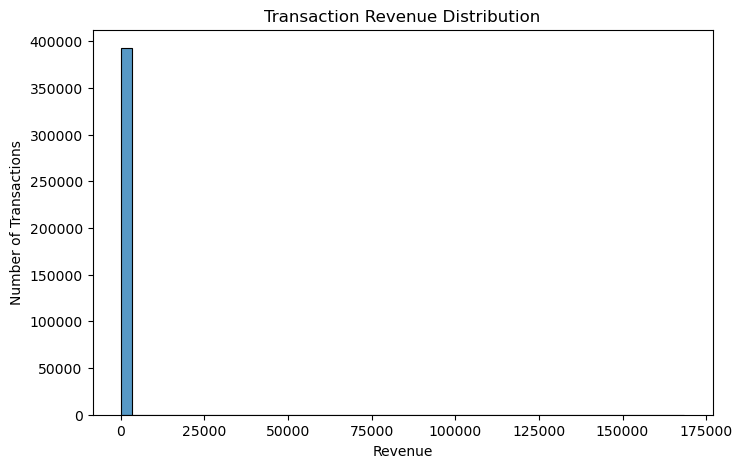

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Revenue"],
    bins=50
)

plt.title("Transaction Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.show()

In [25]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

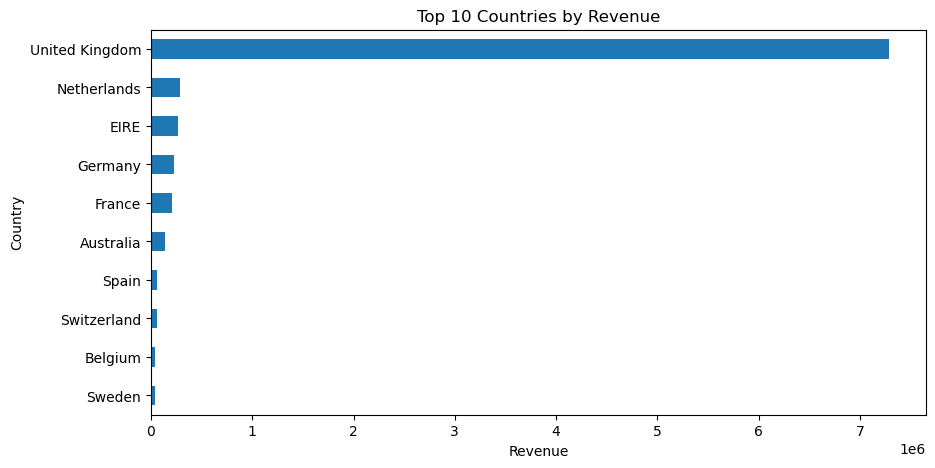

In [26]:
plt.figure(figsize=(10, 5))

country_sales.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

In [27]:
customer_df = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).reset_index()

In [28]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
0,12346.0,2011-01-18 10:01:00,1,77183.60,74215,1
1,12347.0,2011-12-07 15:52:00,7,4310.00,2458,103
2,12348.0,2011-09-25 13:13:00,4,1797.24,2341,22
3,12349.0,2011-11-21 09:51:00,1,1757.55,631,73
4,12350.0,2011-02-02 16:01:00,1,334.40,197,17


In [29]:
customer_df.shape

(4338, 6)

In [30]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [31]:
customer_df["Recency"] = pd.to_datetime(customer_df["Recency"])
customer_df["Recency"] = (
    analysis_date -
    customer_df["Recency"]
).dt.days

customer_df["Recency"].describe()

count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64

In [32]:
customer_df["AverageOrderValue"] = (customer_df["Monetary"] / customer_df["Frequency"])

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue
0,12346.0,326,1,77183.60,74215,1,77183.600000
1,12347.0,2,7,4310.00,2458,103,615.714286
2,12348.0,75,4,1797.24,2341,22,449.310000
3,12349.0,19,1,1757.55,631,73,1757.550000
4,12350.0,310,1,334.40,197,17,334.400000


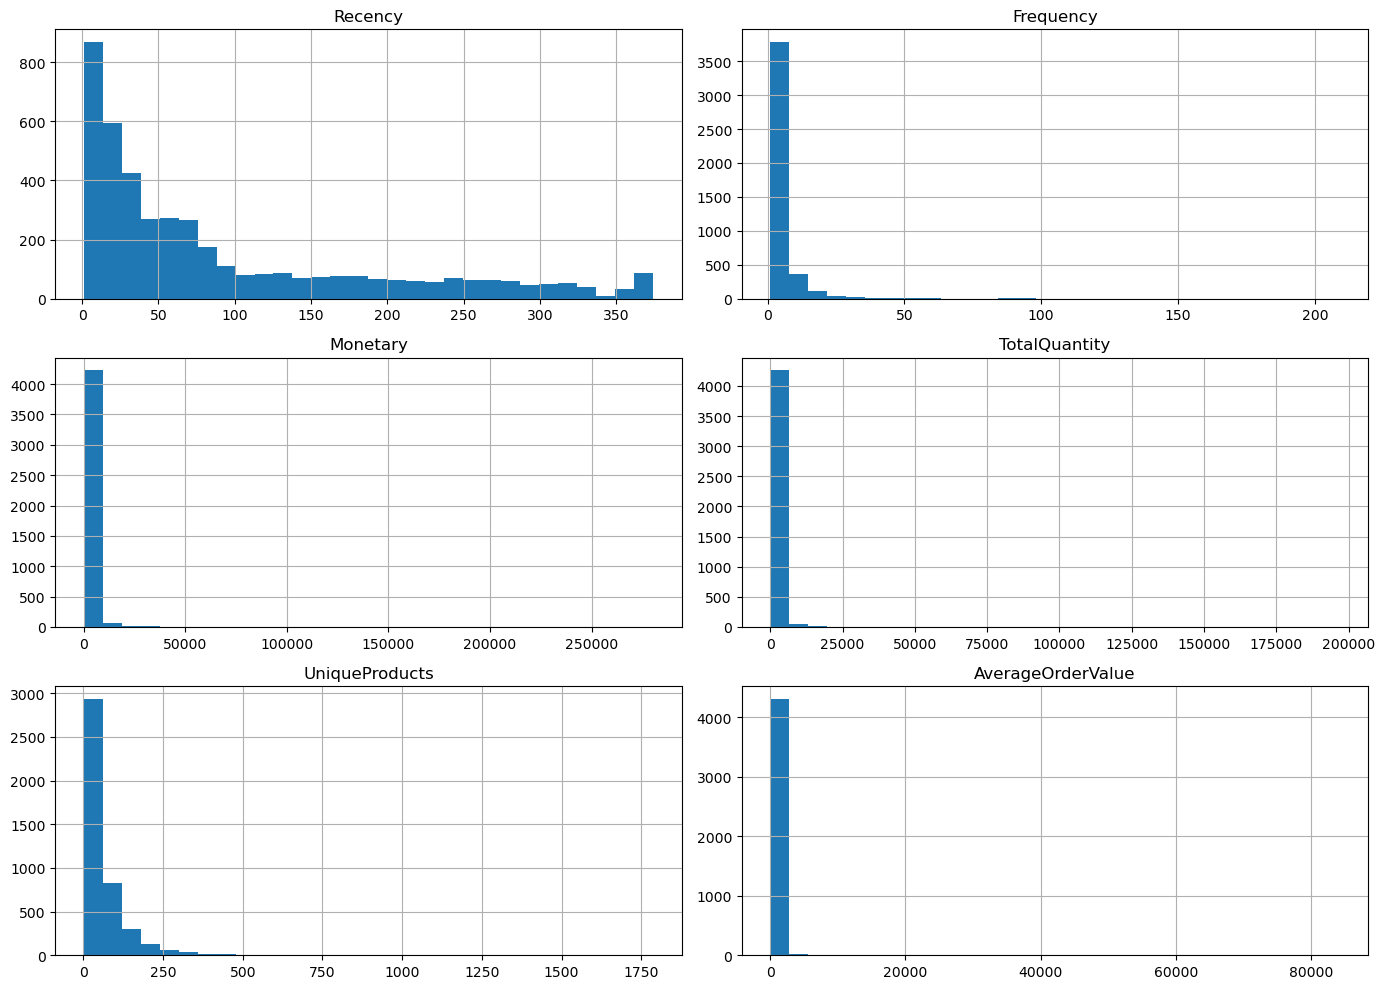

In [33]:
customer_df[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts",
     "AverageOrderValue"]
].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

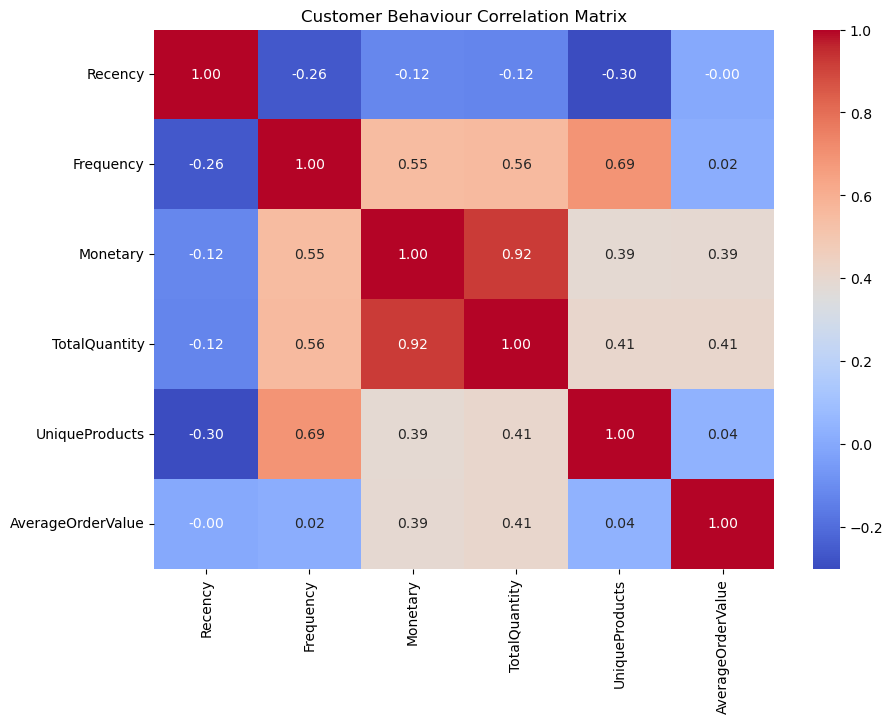

In [34]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    customer_df.drop(
        columns="CustomerID"
    ).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Behaviour Correlation Matrix")

plt.show()

In [35]:
customer_df[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts",
     "AverageOrderValue"]
].skew()

Recency               1.246048
Frequency            12.067031
Monetary             19.339368
TotalQuantity        20.383991
UniqueProducts        6.919445
AverageOrderValue    41.692422
dtype: float64

In [36]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AverageOrderValue"
]

customer_model = customer_df[features].copy()

customer_model = np.log1p(customer_model)

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(customer_model)

In [38]:
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

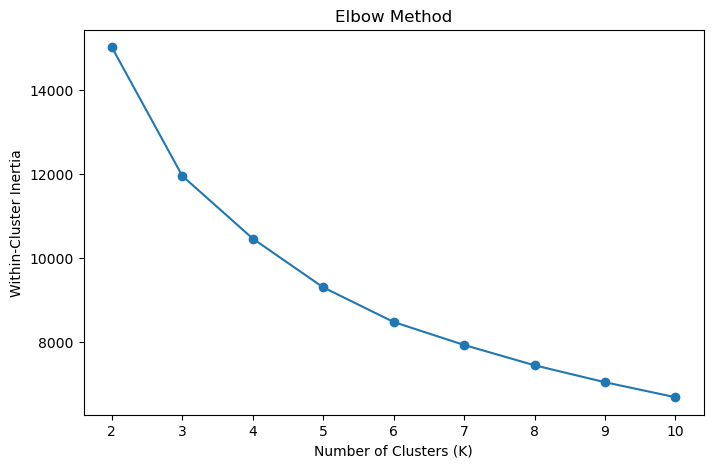

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Inertia")

plt.show()

In [40]:
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels
    )
    silhouette_scores.append(score)

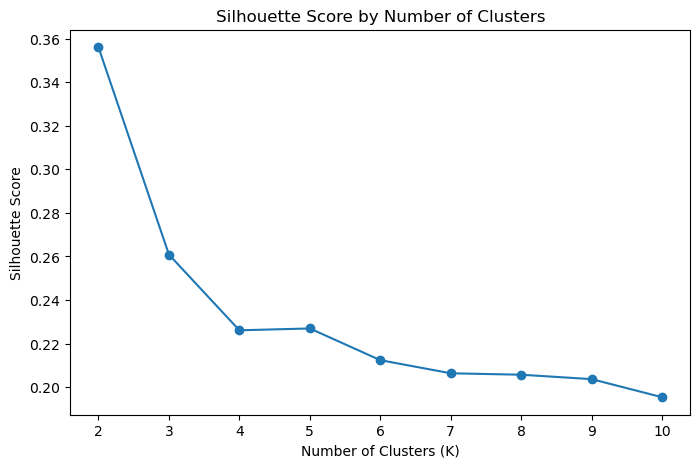

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()

In [42]:
optimal_k = 4
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [43]:
customer_df["Cluster"].value_counts().sort_index()

Cluster
0    1221
1    1265
2    1040
3     812
Name: count, dtype: int64

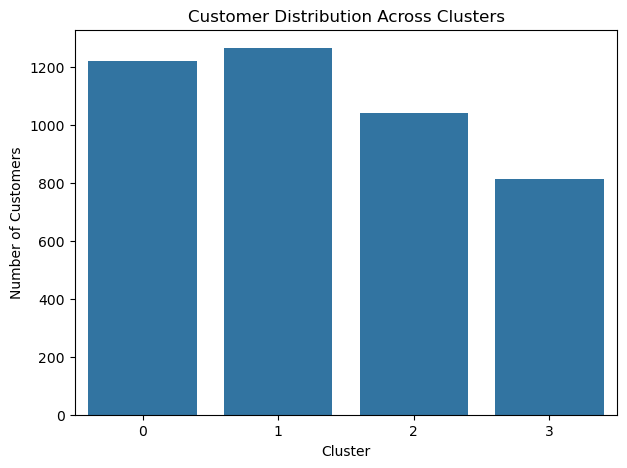

In [44]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=customer_df,
    x="Cluster"
)

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [45]:
cluster_profile = (customer_df.groupby("Cluster")[features].mean().round(2))

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue
Cluster,,,,,,
0,146.66,1.54,718.23,413.89,32.06,491.73
1,36.23,3.98,1104.53,665.44,67.34,301.99
2,151.08,1.45,191.19,106.62,13.22,142.92
3,23.89,12.45,7899.24,4549.23,158.51,838.29


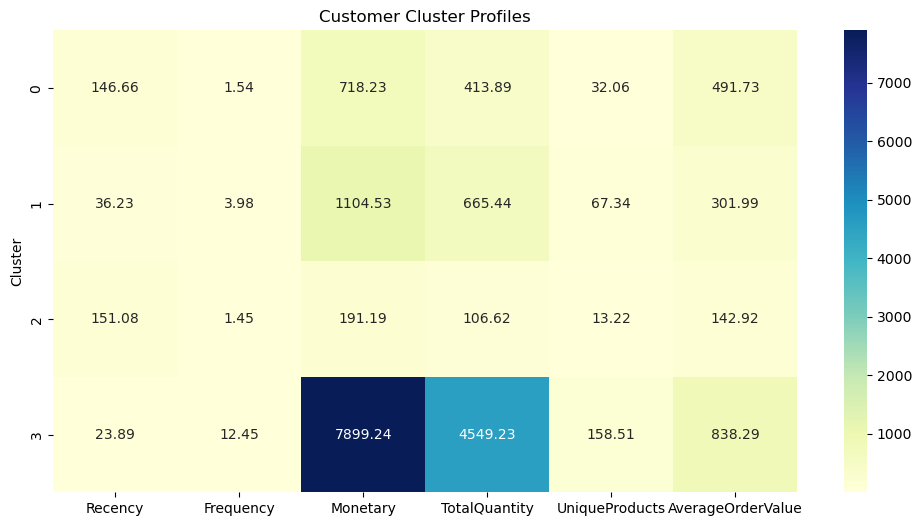

In [46]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Customer Cluster Profiles")

plt.show()

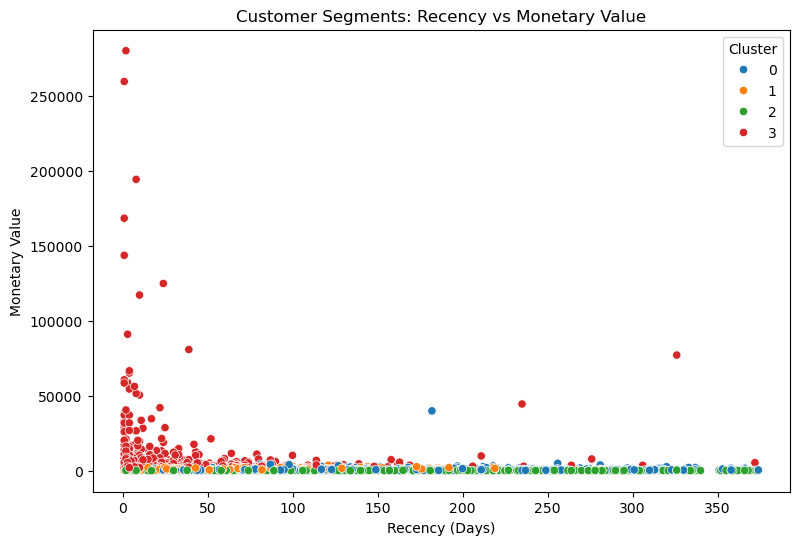

In [47]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_df,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.show()

In [48]:
segment_names = {
    0: "High-Value Loyal",
    1: "Occasional Customers",
    2: "At-Risk Customers",
    3: "New / Potential Customers"
}

customer_df["Segment"] = (
    customer_df["Cluster"]
    .map(segment_names)
)

In [49]:
segment_summary = (
    customer_df
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Avg_Order_Value=("AverageOrderValue", "mean")
    ).round(2)
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Segment,,,,,
At-Risk Customers,1040,151.08,1.45,191.19,142.92
High-Value Loyal,1221,146.66,1.54,718.23,491.73
New / Potential Customers,812,23.89,12.45,7899.24,838.29
Occasional Customers,1265,36.23,3.98,1104.53,301.99


In [50]:
targeting_strategy = {
    "High-Value Loyal":
        "VIP rewards, loyalty benefits and premium offers",

    "Occasional Customers":
        "Personalized promotions and cross-selling",

    "At-Risk Customers":
        "Win-back campaigns and targeted incentives",

    "New / Potential Customers":
        "Onboarding, engagement and repeat-purchase offers"
}

In [51]:
for segment, strategy in targeting_strategy.items():

    print(f"\n{segment}")
    print(strategy)


High-Value Loyal
VIP rewards, loyalty benefits and premium offers

Occasional Customers
Personalized promotions and cross-selling

At-Risk Customers
Win-back campaigns and targeted incentives

New / Potential Customers
Onboarding, engagement and repeat-purchase offers


In [53]:
customer_df.to_csv("../../outputs/customer_segments.csv", index=False)